In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [5]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Total missing values:", df.isnull().sum().sum())

Missing TotalCharges: 11
Total missing values: 0


In [6]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Overall churn rate: 26.54%


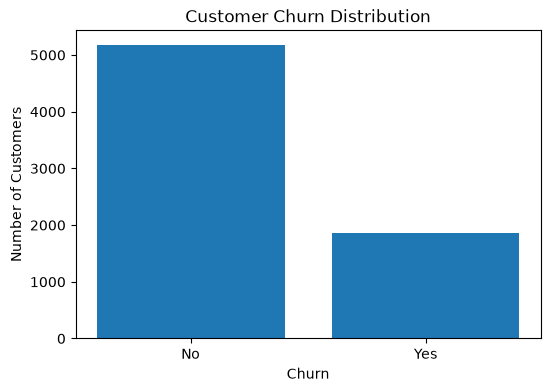

In [7]:
plt.figure(figsize=(6, 4))

plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


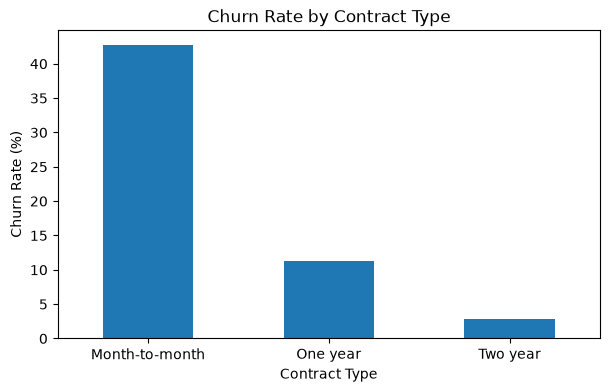

In [9]:
contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [10]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


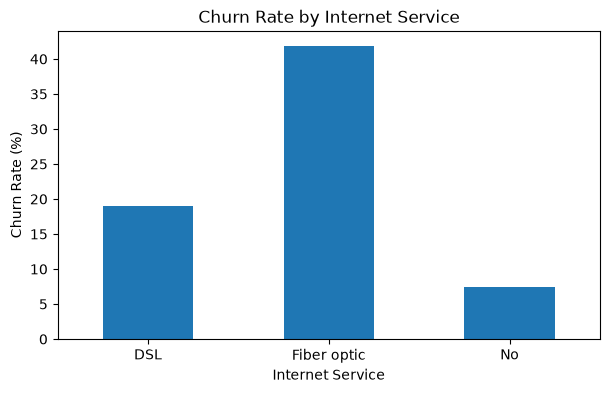

In [11]:
internet_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

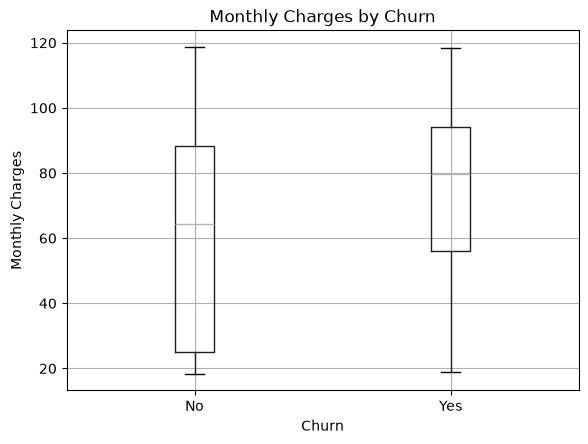

In [12]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

<Figure size 800x500 with 0 Axes>

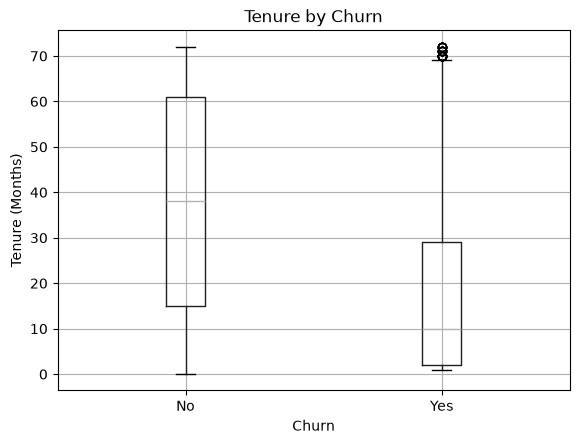

In [13]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [14]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [15]:
df["AvgChargesPerMonth"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

In [16]:
df[["tenure", "MonthlyCharges", "TotalCharges", "AvgChargesPerMonth"]].head()

,tenure,MonthlyCharges,TotalCharges,AvgChargesPerMonth
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [17]:
df = df.drop("customerID", axis=1)

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [19]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Number of features:", X.shape[1])

Number of features: 31


In [20]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgChargesPerMonth,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,29.850000,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,55.573529,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,54.075000,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,40.905556,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,75.825000,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

In [22]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [23]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (4225, 31)
Validation: (1409, 31)
Testing: (1409, 31)


In [24]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgChargesPerMonth"
]

In [25]:
scaler = StandardScaler()

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_val[numerical_columns] = scaler.transform(
    X_val[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [26]:
X_train_np = X_train.values
X_val_np = X_val.values
X_test_np = X_test.values

y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values

In [27]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

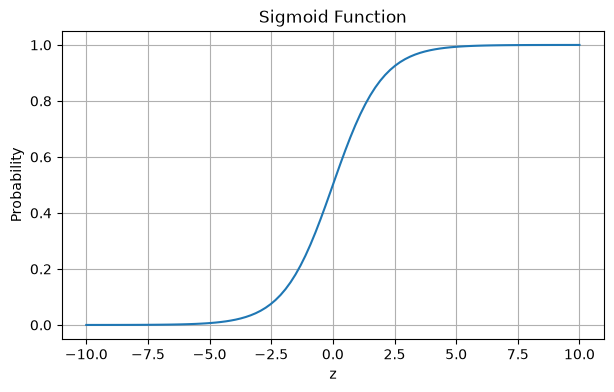

In [28]:
z = np.linspace(-10, 10, 100)

plt.figure(figsize=(7, 4))

plt.plot(z, sigmoid(z))

plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")

plt.grid()
plt.show()

In [29]:
def predict_probability(X, weights, bias):
    z = np.dot(X, weights) + bias
    return sigmoid(z)

In [30]:
def calculate_cost(y, predictions):
    predictions = np.clip(predictions, 1e-10, 1 - 1e-10)

    cost = -np.mean(
        y * np.log(predictions) +
        (1 - y) * np.log(1 - predictions)
    )

    return cost

In [31]:
def train_logistic_regression(X, y, learning_rate=0.01, iterations=1000):
    
    n_samples, n_features = X.shape
    
    weights = np.zeros(n_features)
    bias = 0
    
    cost_history = []
    
    for i in range(iterations):
        
        predictions = predict_probability(
            X,
            weights,
            bias
        )
        
        error = predictions - y
        
        dw = np.dot(X.T, error) / n_samples
        db = np.mean(error)
        
        weights -= learning_rate * dw
        bias -= learning_rate * db
        
        cost = calculate_cost(y, predictions)
        cost_history.append(cost)
    
    return weights, bias, cost_history

In [32]:
weights, bias, cost_history = train_logistic_regression(
    X_train_np,
    y_train_np,
    learning_rate=0.01,
    iterations=2000
)

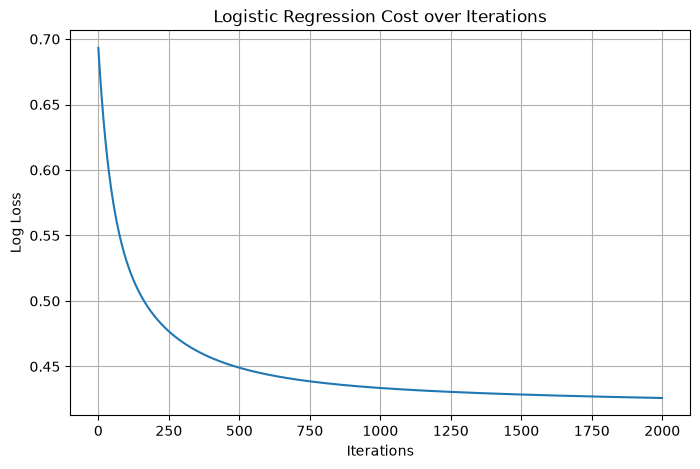

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.title("Logistic Regression Cost over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")

plt.grid()
plt.show()

In [34]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

In [35]:
results = {}

for lr in learning_rates:
    
    weights_lr, bias_lr, cost_lr = train_logistic_regression(
        X_train_np,
        y_train_np,
        learning_rate=lr,
        iterations=2000
    )
    
    results[lr] = cost_lr

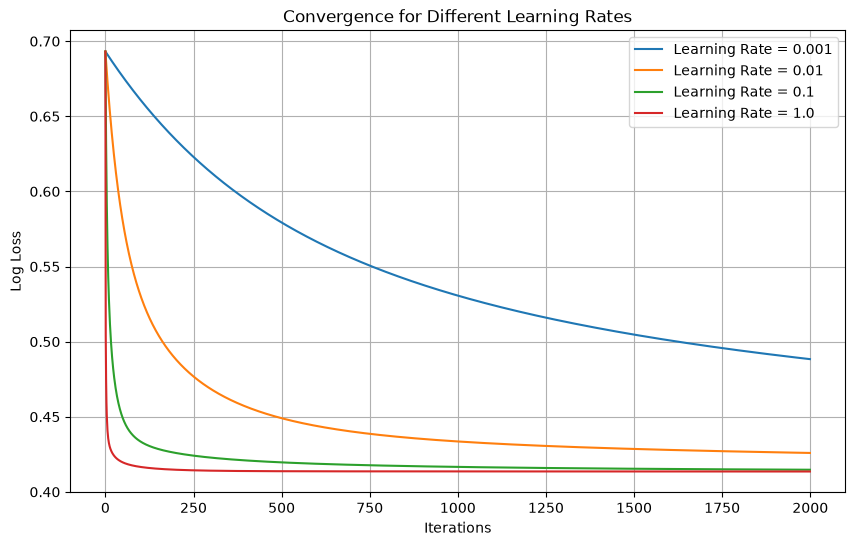

In [36]:
plt.figure(figsize=(10, 6))

for lr, costs in results.items():
    plt.plot(
        costs,
        label=f"Learning Rate = {lr}"
    )

plt.title("Convergence for Different Learning Rates")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.legend()
plt.grid()

plt.show()

In [37]:
for lr, costs in results.items():
    print(f"Learning rate {lr}: Final cost = {costs[-1]:.4f}")

Learning rate 0.001: Final cost = 0.4884
Learning rate 0.01: Final cost = 0.4259
Learning rate 0.1: Final cost = 0.4147
Learning rate 1.0: Final cost = 0.4136


In [38]:
validation_results = {}

for lr in learning_rates:
    
    w, b, costs = train_logistic_regression(
        X_train_np,
        y_train_np,
        learning_rate=lr,
        iterations=2000
    )
    
    val_prob = predict_probability(
        X_val_np,
        w,
        b
    )
    
    validation_loss = calculate_cost(
        y_val_np,
        val_prob
    )
    
    validation_results[lr] = validation_loss

validation_results

{0.001: np.float64(0.48621168272234117),
 0.01: np.float64(0.4174137837470144),
 0.1: np.float64(0.4032301675839063),
 1.0: np.float64(0.40135890577085237)}

In [39]:
best_learning_rate = min(
    validation_results,
    key=validation_results.get
)

print("Best learning rate:", best_learning_rate)

Best learning rate: 1.0


In [40]:
weights, bias, cost_history = train_logistic_regression(
    X_train_np,
    y_train_np,
    learning_rate=best_learning_rate,
    iterations=3000
)

In [41]:
test_probabilities = predict_probability(
    X_test_np,
    weights,
    bias
)

In [42]:
test_predictions = (test_probabilities >= 0.5).astype(int)

In [43]:
TP = np.sum((y_test_np == 1) & (test_predictions == 1))
TN = np.sum((y_test_np == 0) & (test_predictions == 0))
FP = np.sum((y_test_np == 0) & (test_predictions == 1))
FN = np.sum((y_test_np == 1) & (test_predictions == 0))

accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7885


In [44]:
precision = TP / (TP + FP)

print(f"Precision: {precision:.4f}")

Precision: 0.6188


In [45]:
recall = TP / (TP + FN)

print(f"Recall: {recall:.4f}")

Recall: 0.5294


In [46]:
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score: {f1_score:.4f}")

F1 Score: 0.5706


In [47]:
print("Model Performance")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_score:.4f}")

Model Performance
------------------------------
Accuracy : 0.7885
Precision: 0.6188
Recall   : 0.5294
F1 Score : 0.5706


In [48]:
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[913 122]
 [176 198]]


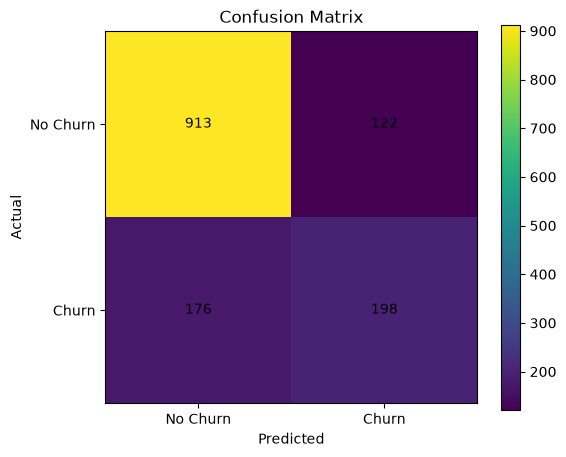

In [49]:
plt.figure(figsize=(6, 5))

plt.imshow(confusion_matrix)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [50]:
fpr, tpr, thresholds = roc_curve(
    y_test_np,
    test_probabilities
)

auc_score = roc_auc_score(
    y_test_np,
    test_probabilities
)

print(f"AUC: {auc_score:.4f}")

AUC: 0.8327


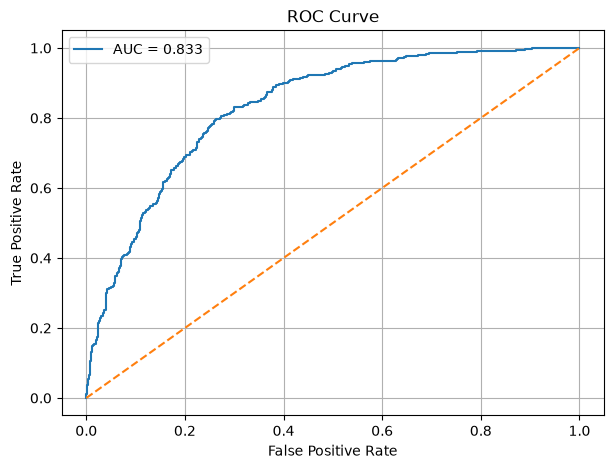

In [51]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": weights
})

In [53]:
feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

In [54]:
feature_importance["Importance"] = (
    feature_importance["Coefficient"].abs()
)

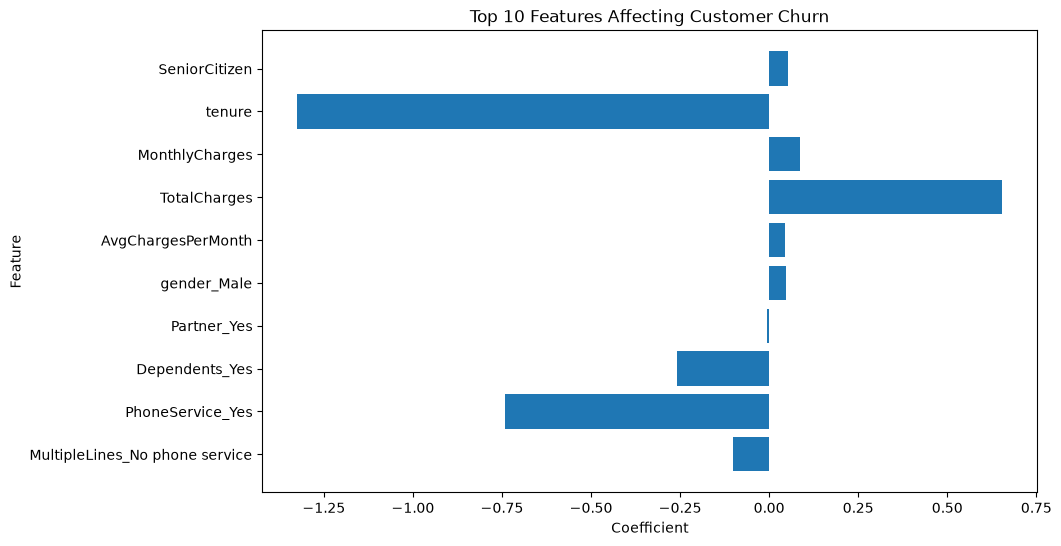

In [55]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.title("Top 10 Features Affecting Customer Churn")

plt.gca().invert_yaxis()

plt.show()

In [56]:
positive_features = feature_importance[
    feature_importance["Coefficient"] > 0
].head(10)

negative_features = feature_importance[
    feature_importance["Coefficient"] < 0
].sort_values(
    "Coefficient"
).head(10)

In [57]:
print("Strongest positive churn predictors:")
print(
    positive_features[
        ["Feature", "Coefficient"]
    ]
)

Strongest positive churn predictors:
                        Feature  Coefficient
0                 SeniorCitizen     0.053646
2                MonthlyCharges     0.087888
3                  TotalCharges     0.653408
4            AvgChargesPerMonth     0.043932
5                   gender_Male     0.047881
10            MultipleLines_Yes     0.246208
11  InternetService_Fiber optic     0.598389
22              StreamingTV_Yes     0.096736
24          StreamingMovies_Yes     0.171689
27         PaperlessBilling_Yes     0.386053


In [58]:
print("\nStrongest negative churn predictors:")
print(
    negative_features[
        ["Feature", "Coefficient"]
    ]
)



Strongest negative churn predictors:
                            Feature  Coefficient
26                Contract_Two year    -1.394415
1                            tenure    -1.324134
8                  PhoneService_Yes    -0.741560
25                Contract_One year    -0.712840
14               OnlineSecurity_Yes    -0.451396
20                  TechSupport_Yes    -0.442183
7                    Dependents_Yes    -0.257445
16                 OnlineBackup_Yes    -0.209333
21  StreamingTV_No internet service    -0.103827
19  TechSupport_No internet service    -0.103827


In [59]:

feature_importance["OddsRatio"] = np.exp(
    feature_importance["Coefficient"]
)

feature_importance.head(10)

,Feature,Coefficient,Importance,OddsRatio
0,SeniorCitizen,0.053646,0.053646,1.055111
1,tenure,-1.324134,1.324134,0.266033
2,MonthlyCharges,0.087888,0.087888,1.091866
3,TotalCharges,0.653408,0.653408,1.922080
4,AvgChargesPerMonth,0.043932,0.043932,1.044911
5,gender_Male,0.047881,0.047881,1.049046
6,Partner_Yes,-0.005294,0.005294,0.994720
7,Dependents_Yes,-0.257445,0.257445,0.773024
8,PhoneService_Yes,-0.741560,0.741560,0.476370
9,MultipleLines_No phone service,-0.102544,0.102544,0.902538


In [60]:
feature_importance.sort_values(
    "Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient,Importance,OddsRatio
3,TotalCharges,0.653408,0.653408,1.922080
11,InternetService_Fiber optic,0.598389,0.598389,1.819185
29,PaymentMethod_Electronic check,0.410577,0.410577,1.507687
27,PaperlessBilling_Yes,0.386053,0.386053,1.471163
10,MultipleLines_Yes,0.246208,0.246208,1.279166
24,StreamingMovies_Yes,0.171689,0.171689,1.187309
22,StreamingTV_Yes,0.096736,0.096736,1.101569
30,PaymentMethod_Mailed check,0.093929,0.093929,1.098481
2,MonthlyCharges,0.087888,0.087888,1.091866
0,SeniorCitizen,0.053646,0.053646,1.055111


In [61]:
churned_customers = df[df["Churn"] == 1]

average_monthly_charge = (
    churned_customers["MonthlyCharges"].mean()
)

print(
    f"Average monthly charge of churned customers: "
    f"${average_monthly_charge:.2f}"
)

Average monthly charge of churned customers: $74.44


In [62]:
estimated_annual_revenue_loss = (
    churned_customers["MonthlyCharges"].sum() * 12
)

print(
    f"Estimated annual revenue impact: "
    f"${estimated_annual_revenue_loss:,.2f}"
)

Estimated annual revenue impact: $1,669,570.20


In [65]:
current_churned = churned_customers.shape[0]

customers_saved = current_churned * 0.10

average_monthly_charge_all = df["MonthlyCharges"].mean()

annual_revenue_saved = (
    customers_saved *
    average_monthly_charge_all *
    12
)

print(
    f"Customers potentially retained: "
    f"{customers_saved:.0f}"
)

print(
    f"Estimated annual revenue preserved: "
    f"${annual_revenue_saved:,.2f}"
)                                                                                                                                                           

Customers potentially retained: 187
Estimated annual revenue preserved: $145,247.52


In [66]:
all_X = X.copy()

all_X[numerical_columns] = scaler.transform(
    all_X[numerical_columns]
)

all_probabilities = predict_probability(
    all_X.values,
    weights,
    bias
)

In [67]:
customer_risk = df.copy()

customer_risk["ChurnProbability"] = all_probabilities

customer_risk["RiskLevel"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

In [68]:
high_risk_customers = customer_risk[
    customer_risk["RiskLevel"] == "High"
]

high_risk_customers[
    [
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "ChurnProbability",
        "RiskLevel"
    ]
].head(10)

,tenure,MonthlyCharges,Contract,InternetService,ChurnProbability,RiskLevel
5,8,99.65,Month-to-month,Fiber optic,0.790106,High
20,1,39.65,Month-to-month,DSL,0.751266,High
31,2,95.50,Month-to-month,Fiber optic,0.721422,High
47,2,80.65,Month-to-month,Fiber optic,0.723089,High
55,18,95.45,Month-to-month,Fiber optic,0.777348,High
64,9,94.40,Month-to-month,Fiber optic,0.709395,High
122,3,74.40,Month-to-month,Fiber optic,0.753270,High
130,13,85.95,Month-to-month,Fiber optic,0.739261,High
133,1,35.45,Month-to-month,DSL,0.723542,High
171,2,104.40,Month-to-month,Fiber optic,0.745839,High


In [69]:
print("Business Recommendations")
print("-" * 50)

print("""
1. Customers on month-to-month contracts should be targeted
   with discounts and long-term contract offers.

2. New customers with low tenure should receive onboarding
   support and early engagement offers.

3. Customers with high monthly charges should be given
   personalized pricing or service bundles.

4. High-risk customers can be identified using the predicted
   churn probability and contacted before they leave.

5. Loyalty programs and contract renewal incentives can help
   reduce customer churn.

6. The company can prioritize retention campaigns based on
   expected revenue impact instead of contacting every customer.
""")

Business Recommendations
--------------------------------------------------

1. Customers on month-to-month contracts should be targeted
   with discounts and long-term contract offers.

2. New customers with low tenure should receive onboarding
   support and early engagement offers.

3. Customers with high monthly charges should be given
   personalized pricing or service bundles.

4. High-risk customers can be identified using the predicted
   churn probability and contacted before they leave.

5. Loyalty programs and contract renewal incentives can help
   reduce customer churn.

6. The company can prioritize retention campaigns based on
   expected revenue impact instead of contacting every customer.

